# F1 Dual-Stage Baseline

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import IN_RACE_PATH, PRE_RACE_PATH, TEST_YEAR, TRAIN_YEARS, VAL_YEAR
from src.metrics import metrics_table, regression_metrics
from src.modeling import (
    IN_RACE_FEATURES,
    IN_RACE_FEATURES_ABLATION,
    PRE_RACE_FEATURES,
    encode_categoricals,
    fill_numeric,
    oof_pre_race_predictions,
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 5)

FIGURES_DIR = ROOT / "figures" / "baseline"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(name: str, dpi: int = 150) -> Path:
    """Save the current matplotlib figure under figures/baseline/."""
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved {path}")
    return path

print("Train years:", TRAIN_YEARS, "| Val:", VAL_YEAR, "| Test:", TEST_YEAR)

Train years: [2019, 2020, 2021, 2022, 2023] | Val: 2024 | Test: 2025


## 1. Load processed data

In [2]:
pre = pd.read_parquet(PRE_RACE_PATH)
laps = pd.read_parquet(IN_RACE_PATH)

print("Pre-race:", pre.shape)
print(pre.groupby("year").size())
print("\nIn-race laps:", laps.shape)
print(laps.groupby("year").size())
pre.head()

Pre-race: (3035, 18)
year
2019    420
2020    340
2021    439
2022    439
2023    439
2024    479
2025    479
dtype: int64

In-race laps: (163397, 20)
year
2019    23392
2020    16951
2021    23303
2022    23050
2023    23983
2024    26381
2025    26337
dtype: int64


,year,round,event_name,circuit,race_id,driver,driver_number,team,grid_position,finish_position,weather_air_temp,weather_track_temp,weather_humidity,weather_rainfall,driver_roll_finish_5,team_roll_finish_5,track_avg_finish,driver_quali_race_conv
0,2019,1,Australian Grand Prix,Melbourne,2019_R1,ALB,23,Toro Rosso,13.0,14.0,23.169231,37.770513,69.102564,0.0,NaN,NaN,NaN,NaN
1,2019,1,Australian Grand Prix,Melbourne,2019_R1,BOT,77,Mercedes,2.0,1.0,23.169231,37.770513,69.102564,0.0,NaN,NaN,NaN,NaN
2,2019,1,Australian Grand Prix,Melbourne,2019_R1,GAS,10,Red Bull Racing,17.0,11.0,23.169231,37.770513,69.102564,0.0,NaN,NaN,NaN,NaN
3,2019,1,Australian Grand Prix,Melbourne,2019_R1,GIO,99,Alfa Romeo Racing,14.0,15.0,23.169231,37.770513,69.102564,0.0,NaN,NaN,NaN,NaN
4,2019,1,Australian Grand Prix,Melbourne,2019_R1,GRO,8,Haas F1 Team,6.0,18.0,23.169231,37.770513,69.102564,0.0,NaN,NaN,NaN,NaN


## 2. Chronological splits + preprocessing

In [3]:
pre_train = pre[pre["year"].isin(TRAIN_YEARS)].copy()
pre_val = pre[pre["year"] == VAL_YEAR].copy()
pre_test = pre[pre["year"] == TEST_YEAR].copy()

_, (pre_train, pre_val, pre_test) = encode_categoricals(pre_train, pre_val, pre_test)

pre_num_cols = [
    c for c in PRE_RACE_FEATURES if c not in ("driver_enc", "team_enc", "circuit_enc")
]
pre_train, pre_val, pre_test = fill_numeric(
    pre_train, pre_val, pre_test, cols=pre_num_cols + ["driver_enc", "team_enc", "circuit_enc"]
)

print(len(pre_train), len(pre_val), len(pre_test))
pre_train[PRE_RACE_FEATURES + ["finish_position"]].describe().T

2077 479 479


,count,mean,std,min,25%,50%,75%,max
grid_position,2077.0,10.130477,5.818450,0.000000,5.000000,10.000000,15.000000,20.000000
driver_roll_finish_5,2077.0,10.451605,4.190810,1.000000,7.200000,10.800000,13.800000,20.000000
team_roll_finish_5,2077.0,10.493741,4.188678,1.400000,7.200000,10.800000,13.800000,18.400000
track_avg_finish,2077.0,10.121634,3.846645,1.000000,8.666667,10.500000,11.000000,20.000000
driver_quali_race_conv,2077.0,-0.342602,2.657995,-12.000000,-2.000000,-0.200000,1.400000,9.000000
weather_air_temp,2077.0,23.321921,4.942415,9.396000,20.538346,23.121481,26.962821,36.565854
weather_track_temp,2077.0,35.196240,9.230182,13.502344,29.511392,34.993590,42.070253,54.461719
weather_humidity,2077.0,55.287648,16.735387,7.109756,43.653846,56.733708,63.901235,96.435862
weather_rainfall,2077.0,0.192585,0.394425,0.000000,0.000000,0.000000,0.000000,1.000000
driver_enc,2077.0,17.477612,9.409139,0.000000,9.000000,19.000000,26.000000,32.000000


## 3. Pre-race Random Forest + grid naive baseline

In [4]:
oof_preds, rf_model = oof_pre_race_predictions(pre_train, PRE_RACE_FEATURES)
pre_train = pre_train.copy()
pre_train["pre_race_pred"] = oof_preds

pre_val = pre_val.copy()
pre_test = pre_test.copy()
pre_val["pre_race_pred"] = rf_model.predict(pre_val[PRE_RACE_FEATURES])
pre_test["pre_race_pred"] = rf_model.predict(pre_test[PRE_RACE_FEATURES])

pre_metric_rows = []
for split_name, df in [("val", pre_val), ("test", pre_test)]:
    pre_metric_rows.append(
        {"model": "RF pre-race", "split": split_name, **regression_metrics(df["finish_position"], df["pre_race_pred"])}
    )
    pre_metric_rows.append(
        {
            "model": "Naive grid",
            "split": split_name,
            **regression_metrics(df["finish_position"], df["grid_position"]),
        }
    )

pre_metrics_df = metrics_table(pre_metric_rows)
pre_metrics_df

,model,split,mae,rmse,top1_exact,top3_hit,top10_hit
0,RF pre-race,val,3.096275,4.005111,0.093946,0.665971,0.974948
1,Naive grid,val,2.906054,4.247067,0.154489,0.718163,0.970772
2,RF pre-race,test,3.470353,4.345233,0.083507,0.569937,0.977035
3,Naive grid,test,3.344468,4.805616,0.183716,0.638831,0.937370


## 4. Merge `pre_race_pred` onto lap rows + in-race preprocessing

In [5]:
pred_map = pd.concat(
    [
        pre_train[["race_id", "driver", "pre_race_pred", "circuit", "team"]],
        pre_val[["race_id", "driver", "pre_race_pred", "circuit", "team"]],
        pre_test[["race_id", "driver", "pre_race_pred", "circuit", "team"]],
    ],
    ignore_index=True,
)

laps_m = laps.merge(
    pred_map[["race_id", "driver", "pre_race_pred"]],
    on=["race_id", "driver"],
    how="inner",
)

lap_train = laps_m[laps_m["year"].isin(TRAIN_YEARS)].copy()
lap_val = laps_m[laps_m["year"] == VAL_YEAR].copy()
lap_test = laps_m[laps_m["year"] == TEST_YEAR].copy()

fill_cols = [c for c in IN_RACE_FEATURES if c != "pre_race_pred"] + ["pre_race_pred"]
lap_train, lap_val, lap_test = fill_numeric(lap_train, lap_val, lap_test, cols=fill_cols)

print(lap_train.shape, lap_val.shape, lap_test.shape)
lap_train[IN_RACE_FEATURES + ["finish_position"]].describe().T

(110679, 21) (26381, 21) (26337, 21)


,count,mean,std,min,25%,50%,75%,max
current_position,110679.0,9.758572,5.412193,1.000000,5.000000,10.00000,14.000000,20.000000
gap_to_leader,110679.0,80.153962,94.014216,0.000000,18.842000,51.12700,103.179000,770.768000
gap_ahead,110679.0,6.931398,47.223471,-621.252000,1.114000,2.70400,7.162500,693.967000
gap_behind,110679.0,6.931398,47.223471,-621.252000,1.114000,2.70400,7.162500,693.967000
tyre_age,110679.0,14.956044,10.220382,1.000000,7.000000,13.00000,21.000000,69.000000
stint_number,110679.0,2.075687,0.988225,1.000000,1.000000,2.00000,3.000000,8.000000
pit_this_lap,110679.0,0.031560,0.174826,0.000000,0.000000,0.00000,0.000000,1.000000
already_pitted,110679.0,0.707397,0.454960,0.000000,0.000000,1.00000,1.000000,1.000000
safety_car_flag,110679.0,0.062641,0.242317,0.000000,0.000000,0.00000,0.000000,1.000000
lap_delta_to_pb,110679.0,2.691600,7.737594,0.000000,0.026000,0.40600,1.116000,75.162000


## 5. In-race XGBoost vs current-position naive

In [6]:
xgb_params = dict(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    n_jobs=-1,
    random_state=42,
)

xgb_coupled = XGBRegressor(**xgb_params)
xgb_coupled.fit(lap_train[IN_RACE_FEATURES], lap_train["finish_position"])

xgb_ablation = XGBRegressor(**xgb_params)
xgb_ablation.fit(lap_train[IN_RACE_FEATURES_ABLATION], lap_train["finish_position"])

lap_metric_rows = []
for split_name, df in [("val", lap_val), ("test", lap_test)]:
    pred_c = xgb_coupled.predict(df[IN_RACE_FEATURES])
    pred_a = xgb_ablation.predict(df[IN_RACE_FEATURES_ABLATION])
    lap_metric_rows.append(
        {"model": "XGB coupled", "split": split_name, **regression_metrics(df["finish_position"], pred_c)}
    )
    lap_metric_rows.append(
        {"model": "XGB ablation", "split": split_name, **regression_metrics(df["finish_position"], pred_a)}
    )
    lap_metric_rows.append(
        {
            "model": "Naive current pos",
            "split": split_name,
            **regression_metrics(df["finish_position"], df["current_position"]),
        }
    )
    df = df.copy()
    df["pred_coupled"] = pred_c
    df["pred_ablation"] = pred_a
    if split_name == "val":
        lap_val = df
    else:
        lap_test = df

lap_metrics_df = metrics_table(lap_metric_rows)
lap_metrics_df

,model,split,mae,rmse,top1_exact,top3_hit,top10_hit
0,XGB coupled,val,1.902297,2.887851,0.240666,0.853796,0.989159
1,XGB ablation,val,1.889931,2.824800,0.240817,0.854782,0.989159
2,Naive current pos,val,1.772298,2.983948,0.340510,0.845419,0.987415
3,XGB coupled,test,2.297334,3.372928,0.186316,0.803053,0.977256
4,XGB ablation,test,2.198984,3.258371,0.193606,0.823328,0.977522
5,Naive current pos,test,2.205187,3.584613,0.309109,0.793029,0.971827


## 6. Combined metrics table

In [7]:
all_metrics = pd.concat([pre_metrics_df, lap_metrics_df], ignore_index=True)
all_metrics = all_metrics.sort_values(["split", "model"]).reset_index(drop=True)
display(all_metrics)

print("\nTest set highlight:")
display(all_metrics[all_metrics["split"] == "test"].round(4))

,model,split,mae,rmse,top1_exact,top3_hit,top10_hit
0,Naive current pos,test,2.205187,3.584613,0.309109,0.793029,0.971827
1,Naive grid,test,3.344468,4.805616,0.183716,0.638831,0.937370
2,RF pre-race,test,3.470353,4.345233,0.083507,0.569937,0.977035
3,XGB ablation,test,2.198984,3.258371,0.193606,0.823328,0.977522
4,XGB coupled,test,2.297334,3.372928,0.186316,0.803053,0.977256
5,Naive current pos,val,1.772298,2.983948,0.340510,0.845419,0.987415
6,Naive grid,val,2.906054,4.247067,0.154489,0.718163,0.970772
7,RF pre-race,val,3.096275,4.005111,0.093946,0.665971,0.974948
8,XGB ablation,val,1.889931,2.824800,0.240817,0.854782,0.989159
9,XGB coupled,val,1.902297,2.887851,0.240666,0.853796,0.989159



Test set highlight:


,model,split,mae,rmse,top1_exact,top3_hit,top10_hit
0,Naive current pos,test,2.2052,3.5846,0.3091,0.7930,0.9718
1,Naive grid,test,3.3445,4.8056,0.1837,0.6388,0.9374
2,RF pre-race,test,3.4704,4.3452,0.0835,0.5699,0.9770
3,XGB ablation,test,2.1990,3.2584,0.1936,0.8233,0.9775
4,XGB coupled,test,2.2973,3.3729,0.1863,0.8031,0.9773


## 7. Plots

Saved /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S3/Applied AI/f1-predictions/figures/baseline/01_feature_importance.png


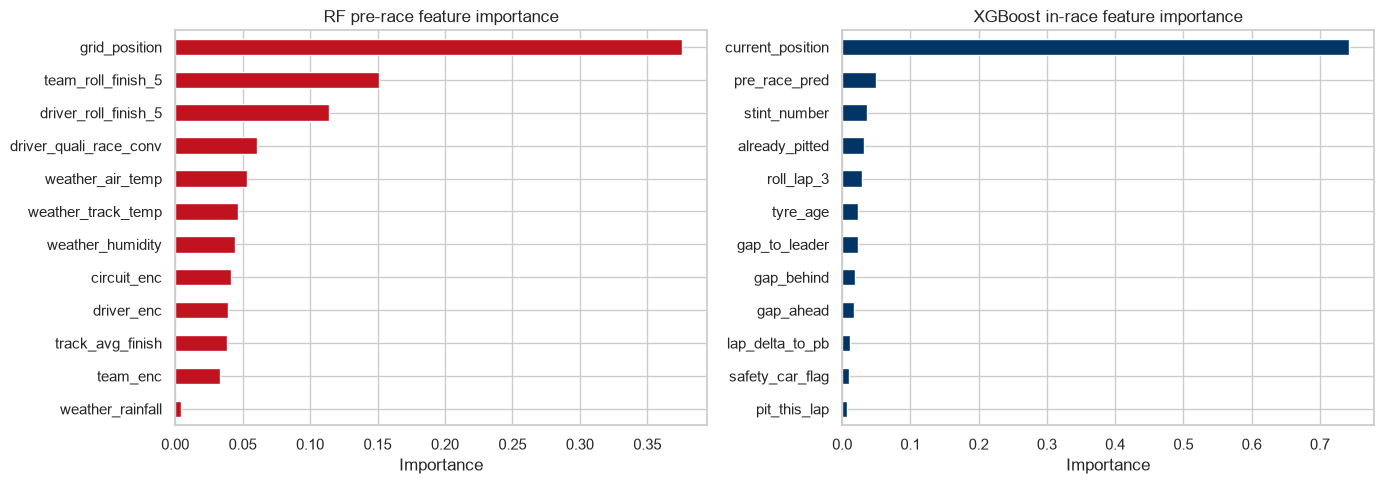

In [8]:
# 7a Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_imp = pd.Series(rf_model.feature_importances_, index=PRE_RACE_FEATURES).sort_values()
rf_imp.plot(kind="barh", ax=axes[0], color="#c1121f")
axes[0].set_title("RF pre-race feature importance")
axes[0].set_xlabel("Importance")

xgb_imp = pd.Series(xgb_coupled.feature_importances_, index=IN_RACE_FEATURES).sort_values()
xgb_imp.plot(kind="barh", ax=axes[1], color="#003566")
axes[1].set_title("XGBoost in-race feature importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
save_figure("01_feature_importance.png")
plt.show()

Saved /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S3/Applied AI/f1-predictions/figures/baseline/02_pred_vs_actual.png


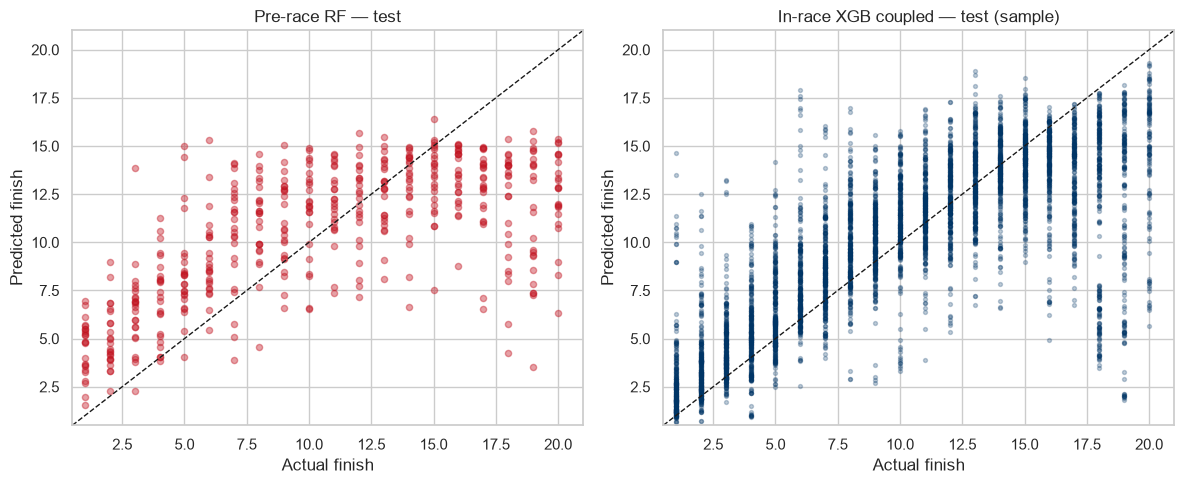

In [9]:
# 7b Predicted vs actual (test)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pre_test["finish_position"], pre_test["pre_race_pred"], alpha=0.4, s=20, c="#c1121f")
lims = [0.5, 21]
axes[0].plot(lims, lims, "k--", lw=1)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].set_xlabel("Actual finish")
axes[0].set_ylabel("Predicted finish")
axes[0].set_title("Pre-race RF — test")

# subsample laps for readability
sample = lap_test.sample(n=min(5000, len(lap_test)), random_state=42)
axes[1].scatter(sample["finish_position"], sample["pred_coupled"], alpha=0.25, s=8, c="#003566")
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("Actual finish")
axes[1].set_ylabel("Predicted finish")
axes[1].set_title("In-race XGB coupled — test (sample)")

plt.tight_layout()
save_figure("02_pred_vs_actual.png")
plt.show()

Saved /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S3/Applied AI/f1-predictions/figures/baseline/03_residuals.png


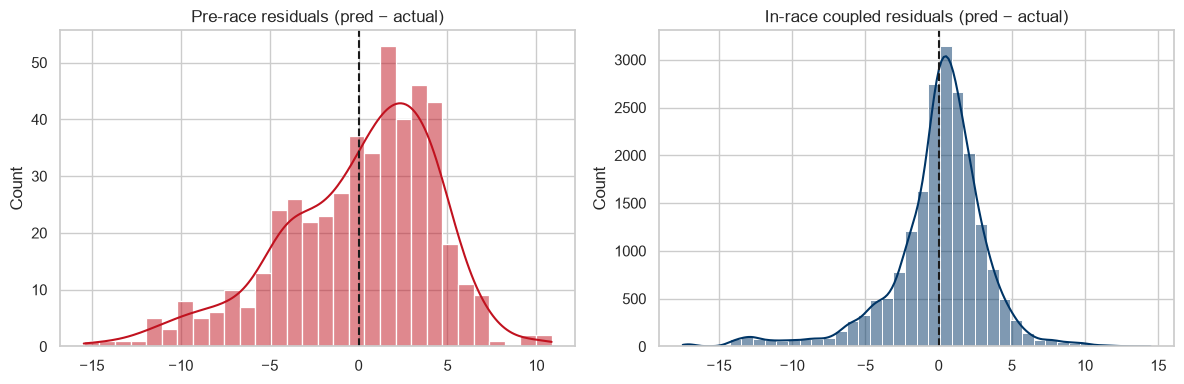

In [10]:
# 7c Residual distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pre_resid = pre_test["pre_race_pred"] - pre_test["finish_position"]
lap_resid = lap_test["pred_coupled"] - lap_test["finish_position"]

sns.histplot(pre_resid, bins=30, ax=axes[0], color="#c1121f", kde=True)
axes[0].axvline(0, color="k", ls="--")
axes[0].set_title("Pre-race residuals (pred − actual)")

sns.histplot(lap_resid.sample(n=min(20000, len(lap_resid)), random_state=42), bins=40, ax=axes[1], color="#003566", kde=True)
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title("In-race coupled residuals (pred − actual)")

plt.tight_layout()
save_figure("03_residuals.png")
plt.show()

Saved /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S3/Applied AI/f1-predictions/figures/baseline/04_mae_vs_lap.png


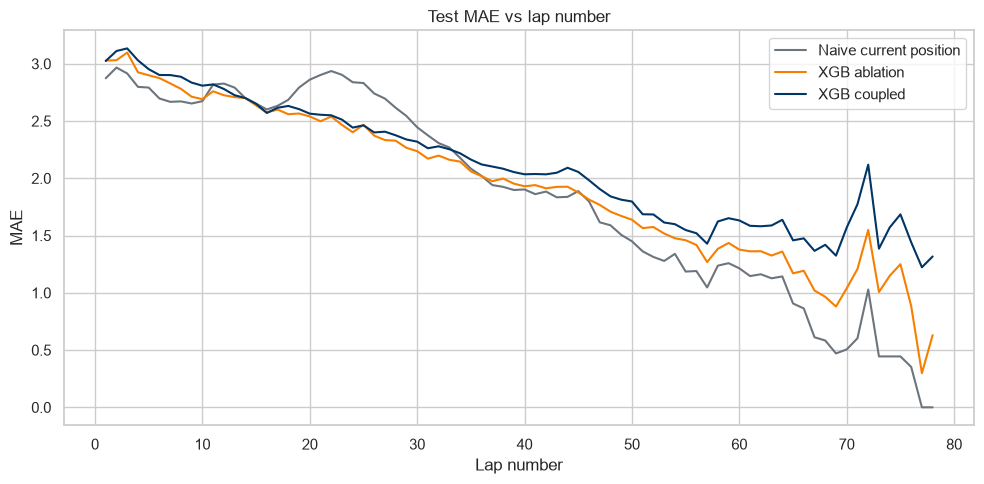

In [11]:
# 7d MAE vs lap number on test
def mae_by_lap(df, pred_col):
    tmp = df.copy()
    tmp["_abs_err"] = np.abs(tmp[pred_col] - tmp["finish_position"])
    return tmp.groupby("lap_number")["_abs_err"].mean()

mae_coupled = mae_by_lap(lap_test, "pred_coupled")
mae_ablation = mae_by_lap(lap_test, "pred_ablation")
mae_naive = mae_by_lap(lap_test.assign(naive=lap_test["current_position"]), "naive")

plt.figure(figsize=(10, 5))
plt.plot(mae_naive.index, mae_naive.values, label="Naive current position", color="#6c757d")
plt.plot(mae_ablation.index, mae_ablation.values, label="XGB ablation", color="#f77f00")
plt.plot(mae_coupled.index, mae_coupled.values, label="XGB coupled", color="#003566")
plt.xlabel("Lap number")
plt.ylabel("MAE")
plt.title("Test MAE vs lap number")
plt.legend()
plt.tight_layout()
save_figure("04_mae_vs_lap.png")
plt.show()

Saved /Users/patrickmarshall/Library/CloudStorage/OneDrive-MilwaukeeSchoolofEngineering/Y4S3/Applied AI/f1-predictions/figures/baseline/05_race_trajectories.png


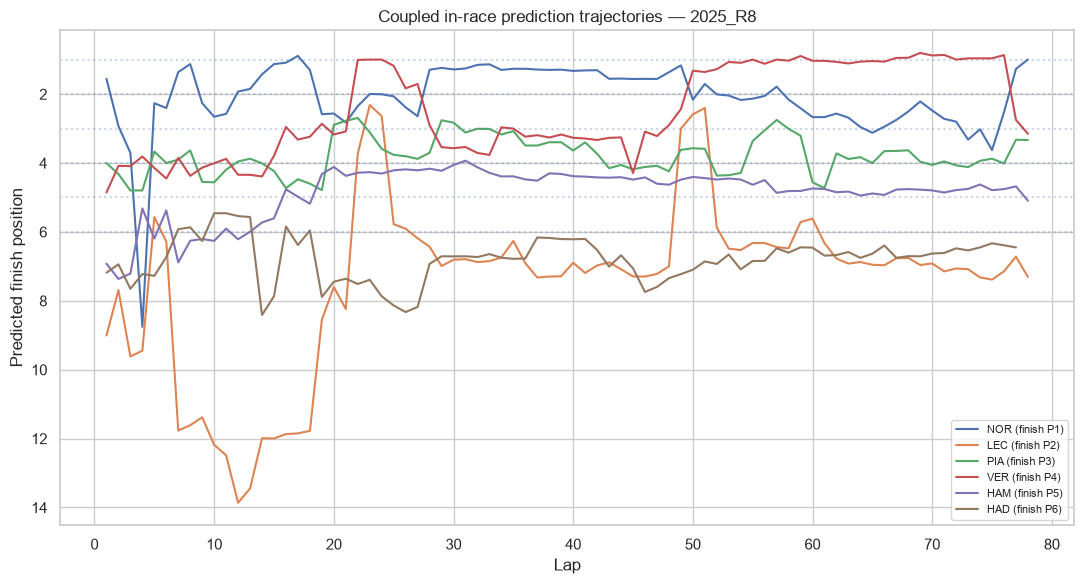

In [12]:
# 7e Example race trajectories
example_race = lap_test["race_id"].value_counts().index[0]
ex = lap_test[lap_test["race_id"] == example_race].copy()
drivers = (
    ex.groupby("driver")["finish_position"].first().sort_values().head(6).index.tolist()
)

plt.figure(figsize=(11, 6))
for drv in drivers:
    d = ex[ex["driver"] == drv].sort_values("lap_number")
    true_finish = d["finish_position"].iloc[0]
    plt.plot(d["lap_number"], d["pred_coupled"], label=f"{drv} (finish P{int(true_finish)})")
    plt.axhline(true_finish, ls=":", alpha=0.3)

plt.xlabel("Lap")
plt.ylabel("Predicted finish position")
plt.title(f"Coupled in-race prediction trajectories — {example_race}")
plt.gca().invert_yaxis()
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
save_figure("05_race_trajectories.png")
plt.show()